순환 신경망은 여러 개의 데이터가 순서대로 입력되었을 때 앞서 입력받은 데이터를 잠시 기억해 놓는 방법이다. 그리고 기억된 데이터가 얼마나 중요한지 판단하고 별도의 가중치를 주어 다음 데이터로 넘어간다.  
모든 입력 값에 이 작업을 순서대로 실행하므로 다음 층으로 넘어가기 전에 같은 층을 맴도는 것처럼 보인다. 이렇게 같은 층 안에서 맴도는 성질때문에 순환 신경망(이하 RNN)이라고 한다.  
순환 신경망(RNN)에 해당하는 '순환' 부분에서는 단어를 하나 처리할 때마다 기억해 다음 입력 값의 출력을 결정한다.

LSTM은 한 층 안에서 반복을 많이 해야 하는 RNN의 특성상 일반 신경망보다 기울기 소실 문제가 더 많이 발생하고 이를 해결하기 어렵다는 단점을 보완할 방법이다. 즉, 반복되기 직전에 다음 층으로 기억된 값을 넘길지 여부를 관리하는 단계를 하나 더 추가하는 것이다.

케라스는 딥러닝 학습에 필요한 데이터를 쉽게 내려받을 수 있게 load_data() 함수를 제공한다. 케라스가 제공하는 '로이터 뉴스 카테고리 분류'를 통해 RNN을 학습해본다.  
로이터 뉴스 데이터는 1만 1,228개의 뉴스 기사가 46개의 카테고리로 나누어진 대용량 텍스트 데이터이다.

In [1]:
# 로이터 뉴스 데이터셋 불러오기
from tensorflow.keras.datasets import reuters

불러온 데이터를 학습셋과 테스트셋으로 나눈다.

In [2]:
# 불러온 데이터를 학습셋과 데이터셋으로 나누기
(X_train, y_train), (X_test, y_test) = reuters.load_data(num_words=1000, test_split=0.2)

num_words 옵션은 무엇을 의미하는지 알아보고자 불러온 데이터에 대해 몇 가지를 출력해 본다.

In [3]:
import numpy as np

# 데이터를 확인한 후 출력해본다.
category = np.max(y_train) + 1
print(category, '카테고리')
print(len(X_train), '학습용 뉴스 기사')
print(len(X_test), '테스트용 뉴스 기사')
print(X_train[0]) # 데이터 안에서 해당 단어가 몇 번이나 나타나는지 세어 빈도에 따라 번호를 붙인다.

46 카테고리
8982 학습용 뉴스 기사
2246 테스트용 뉴스 기사
[1, 2, 2, 8, 43, 10, 447, 5, 25, 207, 270, 5, 2, 111, 16, 369, 186, 90, 67, 7, 89, 5, 19, 102, 6, 19, 124, 15, 90, 67, 84, 22, 482, 26, 7, 48, 4, 49, 8, 864, 39, 209, 154, 6, 151, 6, 83, 11, 15, 22, 155, 11, 15, 7, 48, 9, 2, 2, 504, 6, 258, 6, 272, 11, 15, 22, 134, 44, 11, 15, 16, 8, 197, 2, 90, 67, 52, 29, 209, 30, 32, 132, 6, 109, 15, 17, 12]


테스트셋과 학습셋으로 나눌 때 함께 적용햇던 num_words=1000의 의미는 빈도가 1~1000에 해당하는 단어만 선택해서 불러오는 것이다.

In [4]:
from tensorflow.keras.preprocessing import sequence

# 단어의 수를 맞추어 준다.
X_train = sequence.pad_sequences(X_train, maxlen=100)
X_test = sequence.pad_sequences(X_test, maxlen=100)

maxlen=100은 단어 수를 100개로 맞추라는 의미이다.  
만일 입력된 기사의 단어 수가 100보다 크면 100개째 단어만 선택하고 나머지는 버린다. 100에서 모자랄 때는 모자라는 부분을 모두 0으로 채운다.

y데이터에 원-핫 인코딩 처리를 하여 데이터 전처리 과정을 마친다.

In [5]:
from tensorflow.keras.utils import to_categorical

# 원-핫 인코딩 처리를 한다.
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

딥러닝의 구조를 만든다.

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding

model = Sequential()
model.add(Embedding(1000, 100))
model.add(LSTM(100, activation='tanh'))
model.add(Dense(46, activation='softmax'))

Embedding 층은 데이터 전처리 과정을 통해 입력된 값을 받아 다음 층이 알 수 있는 형태로 변환하는 역할을 한다. Embedding('불러온 단어의 총수', '기사당 단어 수')형식으로 사용하며, 모델 설정 부분의 맨 처음에 있어야 한다.  
  

LSTM은 RNN에서 기억 값에 대한 가중치를 제어하며, LSTM(기사당 단어 수, 기타 옵션) 형식으로 적용된다. LSTM의 활성호 함수로는 tanh를 주로 사용한다.

In [7]:
from tensorflow.keras.callbacks import EarlyStopping

model.compile(loss='categorical_crossentropy', optimizer='adam',
              metrics=['accuracy'])

# 학습의 조기 중단을 설정한다.
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=5)

# 모델을 실행한다.
history = model.fit(X_train, y_train, batch_size=20, epochs=200, validation_data=(X_test, y_test), callbacks=[early_stopping_callback])

Epoch 1/200
450/450 [==============================] - 37s 75ms/step - loss: 2.2248 - accuracy: 0.4380 - val_loss: 1.9065 - val_accuracy: 0.5196
Epoch 2/200
450/450 [==============================] - 8s 18ms/step - loss: 1.7785 - accuracy: 0.5409 - val_loss: 1.7211 - val_accuracy: 0.5695
Epoch 3/200
450/450 [==============================] - 6s 12ms/step - loss: 1.6985 - accuracy: 0.5667 - val_loss: 1.6899 - val_accuracy: 0.5681
Epoch 4/200
450/450 [==============================] - 5s 12ms/step - loss: 1.5862 - accuracy: 0.5880 - val_loss: 1.5714 - val_accuracy: 0.5890
Epoch 5/200
450/450 [==============================] - 6s 14ms/step - loss: 1.4113 - accuracy: 0.6403 - val_loss: 1.4090 - val_accuracy: 0.6465
Epoch 6/200
450/450 [==============================] - 5s 10ms/step - loss: 1.2694 - accuracy: 0.6804 - val_loss: 1.3222 - val_accuracy: 0.6692
Epoch 7/200
450/450 [==============================] - 5s 11ms/step - loss: 1.1677 - accuracy: 0.7084 - val_loss: 1.2741 - val_accuracy

실습| LSTM을 이용한 로이터 뉴스 카테고리 분석하기

46 카테고리
8982 학습용 뉴스 기사
2246 테스트용 뉴스 기사
[1, 2, 2, 8, 43, 10, 447, 5, 25, 207, 270, 5, 2, 111, 16, 369, 186, 90, 67, 7, 89, 5, 19, 102, 6, 19, 124, 15, 90, 67, 84, 22, 482, 26, 7, 48, 4, 49, 8, 864, 39, 209, 154, 6, 151, 6, 83, 11, 15, 22, 155, 11, 15, 7, 48, 9, 2, 2, 504, 6, 258, 6, 272, 11, 15, 22, 134, 44, 11, 15, 16, 8, 197, 2, 90, 67, 52, 29, 209, 30, 32, 132, 6, 109, 15, 17, 12]
Epoch 1/200
450/450 [==============================] - 24s 49ms/step - loss: 2.1562 - accuracy: 0.4408 - val_loss: 1.8300 - val_accuracy: 0.5343
Epoch 2/200
450/450 [==============================] - 6s 13ms/step - loss: 1.8714 - accuracy: 0.5189 - val_loss: 1.8835 - val_accuracy: 0.5067
Epoch 3/200
450/450 [==============================] - 6s 14ms/step - loss: 1.7304 - accuracy: 0.5522 - val_loss: 1.6819 - val_accuracy: 0.5824
Epoch 4/200
450/450 [==============================] - 5s 11ms/step - loss: 1.6241 - accuracy: 0.5924 - val_loss: 1.6174 - val_accuracy: 0.6042
Epoch 5/200
450/450 [================

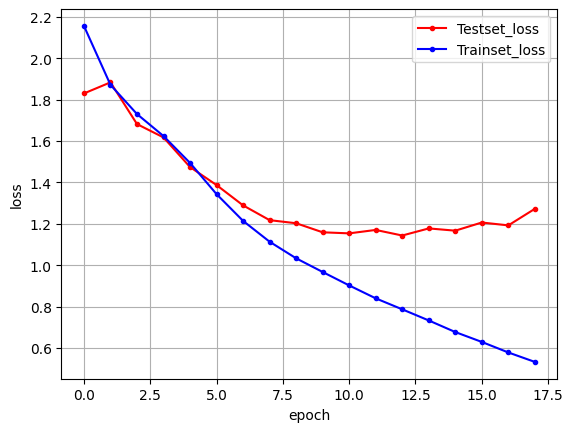

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import reuters
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
import matplotlib.pyplot as plt

# 데이터를 불러와 학습셋, 테스트셋으로 나눈다.
(X_train, y_train), (X_test, y_test) = reuters.load_data(num_words=1000,
                                                         test_split=0.2)

# 데이터를 확인해본다.
category = np.max(y_train) + 1
print(category, '카테고리')
print(len(X_train), '학습용 뉴스 기사')
print(len(X_test), '테스트용 뉴스 기사')
print(X_train[0])

# 단어의 수를 맞추어 준다.
X_train = sequence.pad_sequences(X_train, maxlen=100)
X_test = sequence.pad_sequences(X_test, maxlen=100)

# 원-핫 인코딩 처리를 한다.
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# 모델의 구조를 설정한다.
model = Sequential()
model.add(Embedding(1000, 100))
model.add(LSTM(100, activation='tanh'))
model.add(Dense(46, activation='softmax'))

# 모델의 실행 옵션을 정한다.
model.compile(loss='categorical_crossentropy', optimizer='adam',
              metrics=['accuracy'])

# 학습의 조기 중단을 설정한다.
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=5)

# 모델을 실행한다.
history = model.fit(X_train, y_train, batch_size=20, epochs=200,
                    validation_data=(X_test, y_test), callbacks=[early_stopping_callback])

# 테스트 정확도를 출력한다.
print("\n Test Accuracy: %.4f" % (model.evaluate(X_test, y_test)[1]))

# 검증셋과 학습셋의 오차를 저장한다.
y_vloss = history.history['val_loss']
y_loss = history.history['loss']

# 그래프로 표현해 본다.
x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker='.', c='red', label='Testset_loss')
plt.plot(x_len, y_loss, marker='.', c='blue', label='Trainset_loss')

# 그래프에 그리드를 주고 레이블을 표시한다.
plt.legend(loc="upper right")
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()